# Прекод

# Сборный проект-4

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

# Описание проекта
# Заголовок
- Сборный проект: Демонстрационная версию поиска изображений по запросу
# Описание проекта
- Цель анализа:
    - создать модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.
- Образ результата:
    - модель предсказания насколько текст и картинка подходят друг другу
- Входные данные:
    - train_dataset.csv — информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания
    - test_queries.csv - информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний
    - CrowdAnnotations.tsv — данные по соответствию изображения и описания, полученные с помощью краудсорсинга
    - ExpertAnnotations.tsv - данные по соответствию изображения и описания, полученные в результате опроса экспертов
    - train_images — папка, в которой находятся изображения для тренировки модели
    - test_images - папка, в которой находятся изображения для тестирования модели
# Ход исследования
- Шаг 1. Исследовательский анализ данных
- Шаг 2. Проверка данных
- Шаг 3. Векторизация изображений
- Шаг 4. Векторизация текстов
- Шаг 5. Объединение векторов
- Шаг 6. Обучение модели предсказания соответствия
- Шаг 7. Тестирование модели
- Шаг 8. Выводы
# Рекомендация для заказчика
- Лучшая модель: NN_WideNN
- Модель правильно определяет соответствие в 74.45% случаев
- Создание адекватной системы поиска изображений по запросу возможна, необходимо улучшать модель и выводить ее в продуктив.

## Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


### Загрузка данных (всех)

In [1]:
#Импорт библиотек
import pandas as pd
import zipfile
import requests
import os
import numpy as np

#библиотеки для обработки текста
import re
import nltk
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
#from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
#import transformers
#from tqdm import notebook

#библиотеки для векторизации изображений, модели комп зрения
#!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cpu
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from pathlib import Path

#для bert
import transformers

#для модели
import xgboost as xgb
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.stats import uniform, randint

#для сохранения модели
import joblib

#для выбора случайных запросов
import random

#для времени
import json
import time
from tqdm.notebook import tqdm

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
# 1. Скачиваем архив по ссылке
url = "https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip"
zip_path = "dsplus_integrated_project_4.zip"

print("Скачиваю архив...")
response = requests.get(url)
with open(zip_path, 'wb') as f:
    f.write(response.content)
print("Архив скачан!")

# 2. Распаковываем архив
print("Распаковываю архив...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('data')
print("Архив распакован!")

# 3. Загружаем CSV-файл из папки 'to_upload'
file_path_train = 'data/to_upload/train_dataset.csv'
file_path_test_q = 'data/to_upload/test_queries.csv'
file_path_test_i = 'data/to_upload/test_images.csv'

# 4. Загружаем фото из папки 'to_upload'
path_to_image_folder_test = 'data/to_upload/test_images/'
path_to_image_folder_train = 'data/to_upload/train_images/'

# 5. Загружаем tsv из папки 'to_upload'
file_path_ca = 'data/to_upload/CrowdAnnotations.tsv'
file_path_ea = 'data/to_upload/ExpertAnnotations.tsv'

print("Загружаю данные...")
print("Данные загружены")

Скачиваю архив...
Архив скачан!
Распаковываю архив...
Архив распакован!
Загружаю данные...
Данные загружены


In [3]:
#открытие файла
df_train = pd.read_csv(file_path_train)
df_train.head()

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


In [4]:
#информация о датасете
print(f"информация о датасете df_train: {df_train.info()}")
print(f"количество уникальных image в df_train: {len(df_train['image'].unique())}")
print(f"количество уникальных query_id в df_train: {len(df_train['query_id'].unique())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   query_id    5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB
информация о датасете df_train: None
количество уникальных image в df_train: 1000
количество уникальных query_id в df_train: 977


In [5]:
#открытие файла
df_test_q = pd.read_csv(file_path_test_q, sep='|')
df_test_q.head()

,Unnamed: 0,query_id,query_text,image
0,0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg


In [6]:
#информация о датасете
print(f"информация о датасете df_test_q: {df_test_q.info()}")
print(f"количество уникальных image в df_test_q: {len(df_test_q['image'].unique())}")
print(f"количество уникальных query_id в df_test_q: {len(df_test_q['query_id'].unique())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  500 non-null    int64 
 1   query_id    500 non-null    object
 2   query_text  500 non-null    object
 3   image       500 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.8+ KB
информация о датасете df_test_q: None
количество уникальных image в df_test_q: 100
количество уникальных query_id в df_test_q: 500


In [7]:
#открытие файла
df_test_i = pd.read_csv(file_path_test_i)
df_test_i.head()

,image
0,3356748019_2251399314.jpg
1,2887171449_f54a2b9f39.jpg
2,3089107423_81a24eaf18.jpg
3,1429546659_44cb09cbe2.jpg
4,1177994172_10d143cb8d.jpg


In [8]:
#информация о датасете
print(f"информация о датасете df_test_i: {df_test_i.info()}")
print(f"количество уникальных image в df_test_i: {len(df_test_i['image'].unique())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   100 non-null    object
dtypes: object(1)
memory usage: 928.0+ bytes
информация о датасете df_test_i: None
количество уникальных image в df_test_i: 100


In [9]:
#открытие файла
df_annotations_crowd = pd.read_csv(file_path_ca, sep='\t', 
                                    names=['file_name', 'id_desc', 'share_true', 'qty_true', 'qty_false'])
df_annotations_crowd.head()

,file_name,id_desc,share_true,qty_true,qty_false
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [10]:
#информация о датасете
print(f"информация о датасете df_annotations_crowd: {df_annotations_crowd.info()}")
print(f"количество уникальных file_name в df_annotations_crowd: {len(df_annotations_crowd['file_name'].unique())}")
print(f"количество уникальных id_desc в df_annotations_crowd: {len(df_annotations_crowd['id_desc'].unique())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file_name   47830 non-null  object 
 1   id_desc     47830 non-null  object 
 2   share_true  47830 non-null  float64
 3   qty_true    47830 non-null  int64  
 4   qty_false   47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB
информация о датасете df_annotations_crowd: None
количество уникальных file_name в df_annotations_crowd: 1000
количество уникальных id_desc в df_annotations_crowd: 1000


In [11]:
#открытие файла
df_annotations_expert = pd.read_csv(file_path_ea, sep='\t', 
                                    names=['file_name', 'id_desc', 'r_1', 'r_2', 'r_3'])
df_annotations_expert.head()

,file_name,id_desc,r_1,r_2,r_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [12]:
#информация о датасете
print(f"информация о датасете df_annotations_expert: {df_annotations_expert.info()}")
print(f"количество уникальных file_name в df_annotations_expert: {len(df_annotations_expert['file_name'].unique())}")
print(f"количество уникальных id_desc в df_annotations_expert: {len(df_annotations_expert['id_desc'].unique())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  5822 non-null   object
 1   id_desc    5822 non-null   object
 2   r_1        5822 non-null   int64 
 3   r_2        5822 non-null   int64 
 4   r_3        5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.5+ KB
информация о датасете df_annotations_expert: None
количество уникальных file_name в df_annotations_expert: 1000
количество уникальных id_desc в df_annotations_expert: 977


### Агрегация данных (ExpertAnnotations)

In [13]:
# функция голосования
def get_majority(row):
    votes = [row['r_1'], row['r_2'], row['r_3']]
    for v in set(votes):
        if votes.count(v) >= 2:
            return v
    return None

In [14]:
# использоание функции голосования
df_annotations_expert['final_rating'] = df_annotations_expert.apply(get_majority, axis=1)

In [15]:
# просмотр пустых
df_none = df_annotations_expert[df_annotations_expert['final_rating'].isna()]
df_none.head()

,file_name,id_desc,r_1,r_2,r_3,final_rating
17,1082379191_ec1e53f996.jpg,1536774449_e16b1b6382.jpg#2,1,2,3,NaN
40,1119015538_e8e796281e.jpg,2534502836_7a75305655.jpg#2,2,3,4,NaN
47,1122944218_8eb3607403.jpg,3325497914_f9014d615b.jpg#2,2,3,4,NaN
168,1287475186_2dee85f1a5.jpg,2918769188_565dd48060.jpg#2,1,2,3,NaN
199,1329832826_432538d331.jpg,1536774449_e16b1b6382.jpg#2,1,2,3,NaN


In [16]:
# фильтр
df_filtered_ea = df_annotations_expert.dropna(subset=['final_rating'])

### Объединение данных (ExpertAnnotations и CrowdAnnotations)

In [17]:
# просмотр df_filtered_ea
df_filtered_ea.head()

,file_name,id_desc,r_1,r_2,r_3,final_rating
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1.0
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1.0
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1.0
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,2.0
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1.0


In [18]:
# просмотр df_annotations_crowd
df_annotations_crowd.head()

,file_name,id_desc,share_true,qty_true,qty_false
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [19]:
# колонка оценки в  df_annotations_crowd
df_annotations_crowd['final_rating_crowd'] = df_annotations_crowd['share_true']*4
df_annotations_crowd.head()

,file_name,id_desc,share_true,qty_true,qty_false,final_rating_crowd
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3,0.0
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3,0.0
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3,0.0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3,0.0


In [20]:
# просмотр количество уникальных file_name
print(f"количество уникальных file_name в df_annotations_crowd: {len(df_annotations_crowd['file_name'].unique())}")
print(f"количество уникальных file_name в df_filtered_ea: {len(df_filtered_ea['file_name'].unique())}")

количество уникальных file_name в df_annotations_crowd: 1000
количество уникальных file_name в df_filtered_ea: 1000


In [21]:
# объединяю две таблицы  в одну
data_full = df_annotations_crowd.merge(df_filtered_ea, on='file_name', how='left') 
print(f"количество уникальных file_name в data_full : {len(data_full['file_name'].unique())}")
data_full.head()

количество уникальных file_name в data_full : 1000


,file_name,id_desc_x,share_true,qty_true,qty_false,final_rating_crowd,id_desc_y,r_1,r_2,r_3,final_rating
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,2549968784_39bfbe44f9.jpg#2,1,1,1,1.0
1,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,2718495608_d8533e3ac5.jpg#2,1,1,2,1.0
2,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3181701312_70a379ab6e.jpg#2,1,1,2,1.0
3,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3207358897_bfa61fa3c6.jpg#2,1,2,2,2.0
4,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3286822339_5535af6b93.jpg#2,1,1,2,1.0


In [22]:
#создание колонки, объединяющуюу экспертные  с весом .6  и краудсорсинговые оценки с весом .4 
data_full['final_rating_сombined'] = (data_full['final_rating']*.6 + data_full['final_rating_crowd']*.4)/4
data_full.head()

,file_name,id_desc_x,share_true,qty_true,qty_false,final_rating_crowd,id_desc_y,r_1,r_2,r_3,final_rating,final_rating_сombined
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,2549968784_39bfbe44f9.jpg#2,1,1,1,1.0,0.55
1,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,2718495608_d8533e3ac5.jpg#2,1,1,2,1.0,0.55
2,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3181701312_70a379ab6e.jpg#2,1,1,2,1.0,0.55
3,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3207358897_bfa61fa3c6.jpg#2,1,2,2,2.0,0.70
4,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0,4.0,3286822339_5535af6b93.jpg#2,1,1,2,1.0,0.55


In [23]:
# Проверяем наличие NaN в целевой переменной (final_rating_сombined)
print(f"NaN в final_rating_сombined: {np.isnan(data_full['final_rating_сombined']).sum()}")

NaN в final_rating_сombined: 0


In [24]:
#информация про data_full
data_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 271170 entries, 0 to 271169
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   file_name              271170 non-null  object 
 1   id_desc_x              271170 non-null  object 
 2   share_true             271170 non-null  float64
 3   qty_true               271170 non-null  int64  
 4   qty_false              271170 non-null  int64  
 5   final_rating_crowd     271170 non-null  float64
 6   id_desc_y              271170 non-null  object 
 7   r_1                    271170 non-null  int64  
 8   r_2                    271170 non-null  int64  
 9   r_3                    271170 non-null  int64  
 10  final_rating           271170 non-null  float64
 11  final_rating_сombined  271170 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 26.9+ MB


In [25]:
#Обработка дубликатов
print(f"Явные дубликаты в data_full: {data_full.duplicated().sum()}")
print(f"Уникальные значения в колонке file_name: {data_full['file_name'].nunique()}")
print(f"Уникальные значения в колонке id_desc_x: {data_full['id_desc_x'].nunique()}")

Явные дубликаты в data_full: 0
Уникальные значения в колонке file_name: 1000
Уникальные значения в колонке id_desc_x: 1000


In [26]:
# Создаем минимальный data_full с 2 колонками
data_full_minimal = data_full[['file_name', 'id_desc_y', 'final_rating_сombined']]

print(f"Размер: {data_full_minimal.shape}")
print(f"Колонки: {data_full_minimal.columns.tolist()}")
print(f"\nПервые 5 строк:")
data_full_minimal.head()

Размер: (271170, 3)
Колонки: ['file_name', 'id_desc_y', 'final_rating_сombined']

Первые 5 строк:


,file_name,id_desc_y,final_rating_сombined
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,0.55
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,0.55
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,0.55
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,0.70
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,0.55


**Вывод**
- из df искл. экспертные оценки, где менее 2-х одинаковых оценок из 3-х
- целевая переменная final_rating_сombined объединяет экспертную оценку с весом .6  и краудсорсинговую оценки с весом .4  и варируется от 0 до 1
- получен data_full_minimal  в котором есть уникальные названия картинок (file_name), id_desc, оценка  final_rating_сombined,  размер датасета (271170, 3)

## Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

> This image is unavailable in your country in compliance with local laws
>

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

In [27]:
# Проверка на пропуски
print(f"Пропуски в query_text в df_train: {df_train['query_text'].isnull().sum()}")
print(f"Пропуски в query_text в df_test_q: {df_test_q['query_text'].isnull().sum()}")

Пропуски в query_text в df_train: 0
Пропуски в query_text в df_test_q: 0


In [28]:
# Загрузка ресурсов для обработки текста  (Загрузка необходимых ресурсов NLTK )
nltk.download('stopwords') #Загружает списки стоп-слов (stopwords) для различных языков.
nltk.download('wordnet') #Загружает лексическую базу данных WordNet.
nltk.download('omw-1.4') #Загружает Open Multilingual WordNet версии 1.4 (OMW).
nltk.download('punkt') #Загружает модель пунктуации и токенизации punkt
nltk.download('averaged_perceptron_tagger') #Загружает модель для частеречной разметки (Part-of-Speech tagging) на основе averaged perceptron алгоритма.

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [29]:
# Предобработка текста
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Удаление HTML тегов
    text = re.sub(r'<.*?>', '', text)
    
    # Удаление пунктуации и цифр (оставляем только буквы и пробелы)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def lemmatize_text(text):
    # Токенизация и лемматизация
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

In [30]:
# Применяем очистку
print("Очистка текстов...")
tqdm.pandas()
df_train['query_text_clean']= df_train['query_text'].progress_apply(clean_text)
df_test_q['query_text_clean']= df_test_q['query_text'].progress_apply(clean_text)

print("2 строки из df_train...")
print(df_train.sample(2))
print(" 2 строки из df_test_q...")
print(df_test_q.sample(2))

Очистка текстов...


  0%|          | 0/5822 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

2 строки из df_train...
                          image                     query_id  \
2830   226607225_44d696db6b.jpg  2559921948_06af25d566.jpg#2   
4427  3114944484_28b5bb9842.jpg  2124040721_bffc0a091a.jpg#2   

                                      query_text  \
2830  a little boy at the beach with a surfboard   
4427     An old man with white hair in a red hat   

                                query_text_clean  
2830  a little boy at the beach with a surfboard  
4427     an old man with white hair in a red hat  
 2 строки из df_test_q...
     Unnamed: 0                     query_id  \
112         112  2448210587_9fe7ea5f42.jpg#2   
315         315  3396275223_ee080df8b5.jpg#0   

                                            query_text  \
112  A white bulldog sitting on a tree stump gives ...   
315  A girl is wearing a purple sash and matching s...   

                         image  \
112  2448210587_9fe7ea5f42.jpg   
315  3396275223_ee080df8b5.jpg   

                        

In [31]:
# Лемматизация

wnl = WordNetLemmatizer()

def penn2morphy(penntag):
    """ Converts Penn Treebank tags to WordNet. """
    morphy_tag = {'NN':'n', 'JJ':'a',
                  'VB':'v', 'RB':'r'}
    try:
        return morphy_tag[penntag[:2]]
    except:
        return 'n' 

def lemmatize_sent(text): 
    # Text input is string, returns lowercased strings.
    return [wnl.lemmatize(word.lower(), pos=penn2morphy(tag)) 
            for word, tag in pos_tag(word_tokenize(text))]

In [32]:
# Применяем лемматизацию
print("Лемматизация текстов...")
df_train['processed_query_text'] = df_train['query_text_clean'].progress_apply(lemmatize_sent)
df_test_q['processed_query_text'] = df_test_q['query_text_clean'].progress_apply(lemmatize_sent)

print("5 строк из df_train...")
print(df_train.sample(5))

print(" 5 строк из df_test_q...")
print(df_test_q.sample(5))

Лемматизация текстов...


  0%|          | 0/5822 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

5 строк из df_train...
                          image                     query_id  \
1440  3042380610_c5ea61eef8.jpg  3605061440_1d08c80a57.jpg#2   
3465  3325497914_f9014d615b.jpg  1432179046_8e3d75cf81.jpg#2   
1919   166507476_9be5b9852a.jpg  2938747424_64e64784f0.jpg#2   
5547  2971431335_e192613db4.jpg  3138399980_d6ab8b2272.jpg#2   
3005  1679617928_a73c1769be.jpg   540721368_12ac732c6c.jpg#2   

                                             query_text  \
1440  A group of children gather around a white dog ...   
3465        A man walks toward a car in a parking lot .   
1919  A white dog is running through the water onto ...   
5547  A woman in a park stands with her arm up in th...   
3005  A little girl with a yellow dress blows the wh...   

                                       query_text_clean  \
1440  a group of children gather around a white dog ...   
3465          a man walks toward a car in a parking lot   
1919  a white dog is running through the water onto ...   
5

In [33]:
# Слова/леммы, указывающие на детей (до 16 лет)
child_keywords = [
    'child', 'infant', 'children', 'kids', 'kid',
    'boy', 'girl', 'teenager', 'youth', 'young', 
    'baby', 'newborn', 'schoolchild', 'nursing'
    'preschooler', 'toddler', 'little_one'
]

# Слова, указывающие на возраст 
age_indicators = ['year', 'years', 'age']

In [34]:
# Создаем копию для безопасности
df_train_cleaned = df_train.copy()
#df_test_q_cleaned = df_test_q.copy()

In [35]:
# Флаг наличия упоминаний детей
df_train_cleaned['has_child'] = df_train_cleaned['processed_query_text'].apply(
    lambda x: any(keyword in str(x).lower() for keyword in child_keywords)
)
#df_test_q_cleaned['has_child'] = df_test_q_cleaned['processed_query_text'].apply(
#    lambda x: any(keyword in str(x).lower() for keyword in child_keywords)
#)

In [36]:
# Проверка на возраст
def extract_age_if_child(text):
    # Проверка на пустое значение
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None
    
    # Если text - это список слов, объединяем в строку
    if isinstance(text, list):
        text = ' '.join(text)
    elif not isinstance(text, str):
        text = str(text)
    
    text = text.lower()
    
    # Обновленный паттерн для русского языка (вы использовали английский)
    age_match = re.search(r'(\d{1,2})\s*(?:year|age|years)', text)
    if age_match:
        age = int(age_match.group(1))
        if age <= 16:
            return age
    return None

In [37]:
#применение флагов и функций 
df_train_cleaned['detected_age'] = df_train_cleaned['processed_query_text'].apply(extract_age_if_child)
df_train_cleaned['has_child'] = df_train_cleaned['has_child'] | df_train_cleaned['detected_age'].notna()

In [38]:
# Получаем статистику по df, где detected_age  не None
df_train_cleaned.query('detected_age != None').info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5822 entries, 0 to 5821
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   image                 5822 non-null   object
 1   query_id              5822 non-null   object
 2   query_text            5822 non-null   object
 3   query_text_clean      5822 non-null   object
 4   processed_query_text  5822 non-null   object
 5   has_child             5822 non-null   bool  
 6   detected_age          0 non-null      object
dtypes: bool(1), object(6)
memory usage: 324.1+ KB


*Комментарий*
- Записей нет

In [39]:
# Получаем статистику по df, где has_child не true
df_train_cleaned.query('has_child == True').info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1661 entries, 0 to 5817
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   image                 1661 non-null   object
 1   query_id              1661 non-null   object
 2   query_text            1661 non-null   object
 3   query_text_clean      1661 non-null   object
 4   processed_query_text  1661 non-null   object
 5   has_child             1661 non-null   bool  
 6   detected_age          0 non-null      object
dtypes: bool(1), object(6)
memory usage: 92.5+ KB


*Комментарий*
- Записей 1661

In [40]:
# Получаем sample из 5 записей, где has_child не true
df_train_cleaned[['processed_query_text', 'has_child']].query('has_child == True').sample(5)

,processed_query_text,has_child
4252,"[a, young, woman, sit, on, a, ledge, with, a, ...",True
82,"[a, little, boy, shake, the, snow, off, of, a,...",True
1859,"[a, blonde, girl, surf, down, a, sandy, hill]",True
3555,"[a, young, girl, dress, in, pink, with, a, hai...",True
4153,"[a, boy, with, a, bottle, play, with, an, old,...",True


In [41]:
#применение флагов и функций 
#df_test_q_cleaned['detected_age'] = df_test_q_cleaned['processed_query_text'].apply(extract_age_if_child)
#df_test_q_cleaned['has_child'] = df_test_q_cleaned['has_child'] | df_test_q_cleaned['detected_age'].notna()

In [42]:
# Удаляем строки с детьми
df_filtered_train = df_train_cleaned[~df_train_cleaned['has_child']].drop(['has_child', 'detected_age'], axis=1)
#df_filtered_test_q = df_test_q_cleaned[~df_test_q_cleaned['has_child']].drop(['has_child', 'detected_age'], axis=1)

In [43]:
# Статистика удаления
print(f"Исходное количество df_train: {len(df_train)}")
print(f"Удалено записей с детьми: {(df_train_cleaned['has_child']).sum()}")
print(f"Осталось записей в df_filtered_train: {len(df_filtered_train)}")

#print(f"Исходное количество df_test_q: {len(df_test_q)}")
#print(f"Удалено записей с детьми: {(df_test_q_cleaned['has_child']).sum()}")
#print(f"Осталось записей в df_filtered_test_q: {len(df_filtered_test_q)}")

Исходное количество df_train: 5822
Удалено записей с детьми: 1661
Осталось записей в df_filtered_train: 4161


In [44]:
#переименуем df_filtered_train в df_train_law
df_train_law = df_filtered_train
df_train_law.sample(5)

,image,query_id,query_text,query_text_clean,processed_query_text
5304,3016606751_0e8be20abd.jpg,3716244806_97d5a1fb61.jpg#2,The four people sit on a pile of rocks .,the four people sit on a pile of rocks,"[the, four, people, sit, on, a, pile, of, rock]"
4990,3514019869_7de4ece2a5.jpg,3595643050_d312e4b652.jpg#2,A white dog is standing on its hind legs with ...,a white dog is standing on its hind legs with ...,"[a, white, dog, be, stand, on, it, hind, leg, ..."
1408,1332722096_1e3de8ae70.jpg,2933637854_984614e18b.jpg#2,"A man in an orange jersey with the letter "" 12...",a man in an orange jersey with the letter on i...,"[a, man, in, an, orange, jersey, with, the, le..."
2959,2049051050_20359a434a.jpg,249394748_2e4acfbbb5.jpg#2,Two white dogs running,two white dogs running,"[two, white, dog, run]"
4945,3433982387_3fa993cf5a.jpg,3545586120_283d728a97.jpg#2,Two boxers with white gloves are fighting .,two boxers with white gloves are fighting,"[two, boxer, with, white, glove, be, fight]"


In [45]:
#информация о датасете
print(f"информация о датасете df_train_law: {df_train_law.info()}")
print(f"количество уникальных image в df_train_law: {len(df_train_law['image'].unique())}")
print(f"количество уникальных query_id в df_train_law: {len(df_train_law['query_id'].unique())}")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4161 entries, 22 to 5821
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   image                 4161 non-null   object
 1   query_id              4161 non-null   object
 2   query_text            4161 non-null   object
 3   query_text_clean      4161 non-null   object
 4   processed_query_text  4161 non-null   object
dtypes: object(5)
memory usage: 195.0+ KB
информация о датасете df_train_law: None
количество уникальных image в df_train_law: 991
количество уникальных query_id в df_train_law: 669


**Выводы:**

- 1) данные предобработаны: приведены к нижнему регистру, удалены URL,HTML теги, удалены пунктуация и цифры (оставляем только буквы и пробелы), удалены лишние пробелы
- 2) данные лематизированы
- 3) все изображения, которые нарушают закон (т.е. содержат изображение ребенка), удалены из обучающей выборки. Их кол-во 1661. Для дальнейшего использования df_train_law
- 4) количество уникальных image в df_train_law: 991

## Векторизация изображений

Перейдём к векторизации изображений.

Самый примитивный способ — прочесть изображение и превратить полученную матрицу в вектор. Такой способ нам не подходит: длина векторов может быть сильно разной, так как размеры изображений разные. Поэтому стоит обратиться к свёрточным сетям: они позволяют "выделить" главные компоненты изображений. Как это сделать? Нужно выбрать какую-либо архитектуру, например ResNet-18, посмотреть на слои и исключить полносвязные слои, которые отвечают за конечное предсказание. При этом можно загрузить модель данной архитектуры, предварительно натренированную на датасете ImageNet.

In [46]:
# Загружаем предобученный ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1') #загружаю предварительно обученные веса нейронной сети на датасете ImageNet-1K.
# Замораживаем веса
for param in model.parameters():
    param.requires_grad = False
model.eval()
# Удаляем последний слой fc и avgpool (можно оставить avgpool для стабилизации)
model = torch.nn.Sequential(
    *list(model.children())[:-1]
    )  # теперь выход: [batch, 512, 1, 1] если был avgpool

model = torch.nn.Sequential(
    *list(model.children())[:-2],  # все слои кроме avgpool и fc
    torch.nn.AdaptiveAvgPool2d((1, 1)),
    torch.nn.Flatten()
)

# Трансформация под вход сети
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [47]:
# Функция для векторизации всех изображений в папке
def vectorize_images_in_folder(folder_path):
    """
    Принимает путь к папке с изображениями.
    Возвращает словарь: {имя_файла: вектор_эмбеддинга}
    """
    folder_path = Path(folder_path)
    
    if not folder_path.exists():
        print(f" Папка не найдена: {folder_path}")
        return {}
    
    # Получаем все изображения в папке
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    image_files = [f for f in folder_path.iterdir() 
                   if f.suffix.lower() in image_extensions]
    
    if not image_files:
        print(f" В папке {folder_path} нет изображений")
        return {}
    
    embeddings_dict = {}
    
    with torch.no_grad():
        for img_path in image_files:
            try:
                # Загружаем и преобразуем изображение
                img = Image.open(img_path).convert('RGB')  # convert RGB на случай grayscale
                img_tensor = transform(img).unsqueeze(0)  # добавляем batch dimension
                
                # Получаем эмбеддинг
                embedding = model(img_tensor)
                
                # Сохраняем результат
                embeddings_dict[img_path.name] = embedding[0].cpu().numpy()
                #print(f" Обработано: {img_path.name}")
                
            except Exception as e:
                print(f" Ошибка при обработке {img_path.name}: {e}")
    
    return embeddings_dict


In [48]:
# Загружаем фото из папок (путь обозначен выше в задании 1)

print("Обработка тестовых изображений...")
test_embeddings = vectorize_images_in_folder(path_to_image_folder_test)
print("Обработка тренировочных изображений...")
train_embeddings = vectorize_images_in_folder(path_to_image_folder_train)


Обработка тестовых изображений...
Обработка тренировочных изображений...


In [49]:
# Выводим результаты
print("\n" + "=" * 50)
print(f"Результаты:")
print(f"Тестовых изображений обработано: {len(test_embeddings)}")
print(f"Тренировочных изображений обработано: {len(train_embeddings)}")

if test_embeddings:
    print(f"\nПример вектора для первого тестового изображения:")
    first_test_file = list(test_embeddings.keys())[0]
    print(f"Файл: {first_test_file}")
    print(f"Размер вектора: {test_embeddings[first_test_file].shape}")
    print(f"Первые 5 значений: {test_embeddings[first_test_file][:5]}")


Результаты:
Тестовых изображений обработано: 100
Тренировочных изображений обработано: 1000

Пример вектора для первого тестового изображения:
Файл: 1177994172_10d143cb8d.jpg
Размер вектора: (256,)
Первые 5 значений: [0.22547717 0.1615547  0.09779506 0.18515778 0.09706169]


**Выводы**
- векторизация тестовых и тренировочных изображений произведена

## Векторизация текстов

Следующий этап — векторизация текстов. Вы можете поэкспериментировать с несколькими способами векторизации текстов:

- tf-idf
- word2vec
- \*трансформеры (например Bert)

\* — если вы изучали трансформеры в спринте Машинное обучение для текстов.


In [50]:
#Векторизация текстов при помощи BERT
# Загрузка модели и токенизатора
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-cased')
model = transformers.BertModel.from_pretrained('bert-base-cased')
model.eval()

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [51]:
#функции
def get_bert_embeddings(df, text_column='processed_query_text', max_length=128, batch_size=100):
    """
    Функция для получения BERT эмбеддингов из текстового столбца
    
    Args:
        df: DataFrame с текстами
        text_column: название столбца с текстами
        max_length: максимальная длина последовательности
        batch_size: размер батча
    
    Returns:
        numpy array с эмбеддингами
    """
    # Токенизация
    tokenized = df[text_column].apply(
        lambda x: tokenizer.encode(
            x, 
            add_special_tokens=True, 
            max_length=max_length, 
            truncation=True,
            padding=False  # Не паддим здесь, сделаем позже
        )
    )
    
    # Находим максимальную длину в этом датасете
    # проверяем на пустоту через len(tokenized)
    if len(tokenized) == 0:
        return np.array([])
    
    max_len = max(len(i) for i in tokenized)
    max_len = min(max_len, max_length)  # Ограничиваем max_length
    
    # Паддинг
    padded = np.array([i + [0]*(max_len - len(i)) for i in tokenized.values])
    attention_mask = np.where(padded != 0, 1, 0)
    
    # Извлечение эмбеддингов батчами
    embeddings = []
    
    for i in range(0, padded.shape[0], batch_size):
        batch = torch.LongTensor(padded[i:i+batch_size])
        mask_batch = torch.LongTensor(attention_mask[i:i+batch_size])
        
        with torch.no_grad():
            outputs = model(batch, attention_mask=mask_batch)
        
        # Берём [CLS] эмбеддинг
        cls_embeds = outputs.last_hidden_state[:, 0, :].numpy()
        embeddings.append(cls_embeds)
    
    return np.concatenate(embeddings, axis=0)

In [52]:
# Получаем эмбеддинги для train
print("Векторизация train данных...")
features_train = get_bert_embeddings(df_train_law, 'processed_query_text')

Векторизация train данных...


In [53]:
# Получаем эмбеддинги для test
print("Векторизация test данных...")
features_test = get_bert_embeddings(df_test_q, 'processed_query_text')

Векторизация test данных...


In [54]:
# Проверяем размерности
print(f"\nTrain эмбеддинги: {features_train.shape}")
print(f"Test эмбеддинги: {features_test.shape}")
print(f"Train samples: {len(df_train_law)}")
print(f"Test samples: {len(df_test_q)}")


Train эмбеддинги: (4161, 768)
Test эмбеддинги: (500, 768)
Train samples: 4161
Test samples: 500


**Выводы**
- векторизация текстов (тренировочных и тестовых) произведена

## Объединение векторов

Подготовьте данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

In [55]:
# Проверка размеров
print(f"Размер df_train_law: {len(df_train_law)}")
print(f"Размер features_train: {len(features_train)}")
print(f"Размер train_embeddings: {len(train_embeddings)}")
print(f"Тип train_embeddings: {type(train_embeddings)}")
print(f"Форма train_embeddings: {train_embeddings.shape if hasattr(train_embeddings, 'shape') else 'N/A'}")

print(f"Размер df_test_q: {len(df_test_q)}")
print(f"Размер features_test: {len(features_test)}")
print(f"Размер test_embeddings : {len(test_embeddings )}")
print(f"Тип test_embeddings : {type(test_embeddings )}")
print(f"Форма test_embeddings : {test_embeddings .shape if hasattr(test_embeddings , 'shape') else 'N/A'}")

Размер df_train_law: 4161
Размер features_train: 4161
Размер train_embeddings: 1000
Тип train_embeddings: <class 'dict'>
Форма train_embeddings: N/A
Размер df_test_q: 500
Размер features_test: 500
Размер test_embeddings : 100
Тип test_embeddings : <class 'dict'>
Форма test_embeddings : N/A


In [56]:
# Структура train_embeddings
print("Структура train_embeddings:")
print(f"Ключи: {list(train_embeddings.keys())[:5] if train_embeddings else 'пусто'}")
print(f"Тип значения: {type(list(train_embeddings.values())[0]) if train_embeddings else 'N/A'}")
print(f"Форма первого значения: {train_embeddings[list(train_embeddings.keys())[0]].shape if train_embeddings else 'N/A'}")

# Структура test_embeddings
print("\nСтруктура test_embeddings:")
print(f"Ключи: {list(test_embeddings.keys())[:5] if test_embeddings else 'пусто'}")
print(f"Тип значения: {type(list(test_embeddings.values())[0]) if test_embeddings else 'N/A'}")

Структура train_embeddings:
Ключи: ['1056338697_4f7d7ce270.jpg', '106490881_5a2dd9b7bd.jpg', '1082379191_ec1e53f996.jpg', '1084040636_97d9633581.jpg', '1096395242_fc69f0ae5a.jpg']
Тип значения: <class 'numpy.ndarray'>
Форма первого значения: (256,)

Структура test_embeddings:
Ключи: ['1177994172_10d143cb8d.jpg', '1232148178_4f45cc3284.jpg', '123997871_6a9ca987b1.jpg', '1319634306_816f21677f.jpg', '1429546659_44cb09cbe2.jpg']
Тип значения: <class 'numpy.ndarray'>


*Комментарий*
- train_embeddings и test_embeddings — это словари, где ключи — это названия изображений (image) из колонки image, а значения — эмбеддинги размерностью 256.

In [57]:
# Объединение train данных

print("=" * 50)
print("Объединение train данных")
print("=" * 50)
# Базовый DataFrame для train
df_train_combined = df_train_law.copy()
# Добавляем features_train (BERT эмбеддинги для текстов)
df_train_combined['bert_embeddings'] = list(features_train)
# Добавляем train_embeddings (эмбеддинги изображений) по колонке 'image'
df_train_combined['image_embeddings'] = df_train_combined['image'].map(train_embeddings)
# Проверяем train данные
missing_train_embeddings = df_train_combined['image_embeddings'].isna().sum()
print(f"Всего train строк: {len(df_train_combined)}")
print(f"Строк с image_embeddings: {df_train_combined['image_embeddings'].notna().sum()}")
print(f"Строк без image_embeddings: {missing_train_embeddings}")

Объединение train данных
Всего train строк: 4161
Строк с image_embeddings: 4161
Строк без image_embeddings: 0


In [58]:
# Объединение test данных
print("\n" + "=" * 50)
print("Объединение test данных")
print("=" * 50)

# Базовый DataFrame для test
df_test_combined = df_test_q.copy()

# Добавляем features_test (BERT эмбеддинги для текстов)
df_test_combined['bert_embeddings'] = list(features_test)

# Добавляем test_embeddings (эмбеддинги изображений) по колонке 'image'
df_test_combined['image_embeddings'] = df_test_combined['image'].map(test_embeddings)

# Проверяем test данные
missing_test_embeddings = df_test_combined['image_embeddings'].isna().sum()
print(f"Всего test строк: {len(df_test_combined)}")
print(f"Строк с image_embeddings: {df_test_combined['image_embeddings'].notna().sum()}")
print(f"Строк без image_embeddings: {missing_test_embeddings}")


Объединение test данных
Всего test строк: 500
Строк с image_embeddings: 500
Строк без image_embeddings: 0


In [59]:
# Объединение train и test датасетов

print("=" * 50)
print("# Объединение train и test датасетов")
print("=" * 50)

# вертикальное объединение (добавление строк)
df_all = pd.concat([df_train_combined, df_test_combined], axis=0, ignore_index=True)

print(f"Размер train: {df_train_combined.shape}")
print(f"Размер test: {df_test_combined.shape}")
print(f"Размер объединенного датасета: {df_all.shape}")
print(f"Всего строк: {len(df_all)}")
print(f"Всего колонок: {len(df_all.columns)}")

# ============================================
# ДОБАВЛЕНИЕ ИДЕНТИФИКАТОРА ИСТОЧНИКА
# ============================================
# Добавляем столбец, указывающий на происхождение данных
df_train_combined_with_source = df_train_combined.copy()
df_test_combined_with_source = df_test_combined.copy()

df_train_combined_with_source['source'] = 'train'
df_test_combined_with_source['source'] = 'test'

# Объединяем с идентификатором
df_all_with_source = pd.concat([df_train_combined_with_source, df_test_combined_with_source], 
                                axis=0, ignore_index=True)

print(f"\n--- С идентификатором источника ---")
print(f"Распределение данных:")
print(df_all_with_source['source'].value_counts())

# Объединение train и test датасетов
Размер train: (4161, 7)
Размер test: (500, 8)
Размер объединенного датасета: (4661, 8)
Всего строк: 4661
Всего колонок: 8

--- С идентификатором источника ---
Распределение данных:
train    4161
test      500
Name: source, dtype: int64


In [60]:
#обзор датасета
df_all_with_source= df_all_with_source.drop('Unnamed: 0', axis=1)
df_all_with_source.sample(5)

,image,query_id,query_text,query_text_clean,processed_query_text,bert_embeddings,image_embeddings,source
2505,2708686056_1b8f356264.jpg,1392272228_cf104086e6.jpg#2,A black dog is coming out of the ocean water o...,a black dog is coming out of the ocean water o...,"[a, black, dog, be, come, out, of, the, ocean,...","[0.3174376, 0.17194171, -0.09491902, -0.012849...","[0.21791956, 0.16225563, 0.048433572, 0.060804...",train
333,113678030_87a6a6e42e.jpg,541063517_35044c554a.jpg#2,"A man in grey on a rocky cliff , overlooking t...",a man in grey on a rocky cliff overlooking the...,"[a, man, in, grey, on, a, rocky, cliff, overlo...","[0.18313582, -0.12790243, -0.056332596, -0.138...","[0.10733476, 0.06462381, 0.15631051, 0.1538930...",train
3194,473220329_819a913bbb.jpg,1267711451_e2a754b4f8.jpg#2,a black and white dog walking through the gras...,a black and white dog walking through the gras...,"[a, black, and, white, dog, walk, through, the...","[0.23989302, -0.05989402, -0.004627425, -0.109...","[0.12234528, 0.03690387, 0.17530628, 0.0664542...",train
4377,3044745642_1d0784ff29.jpg,3044745642_1d0784ff29.jpg#1,Men in a khaki-colored tent outside in a rundo...,men in a khakicolored tent outside in a rundow...,"[men, in, a, khakicolored, tent, outside, in, ...","[0.35365292, -0.13263525, -0.12618688, -0.3418...","[0.13482273, 0.24224769, 0.147681, 0.025229853...",test
268,3502993968_4ee36afb0e.jpg,3220126881_b0a4f7cccb.jpg#2,Two men and a woman smile at the camera .,two men and a woman smile at the camera,"[two, men, and, a, woman, smile, at, the, camera]","[0.028954182, -0.12619142, 0.05006085, 0.00708...","[0.11919408, 0.1486995, 0.11278557, 0.04902964...",train


In [61]:
# совпадают ли значения в колонках image и file_name
print("Примеры image из df_all_with_source:", df_all_with_source['image'].head(3).tolist())
print("Примеры file_name из data_full:", data_full['file_name'].head(3).tolist())

Примеры image из df_all_with_source: ['1056338697_4f7d7ce270.jpg', '3187395715_f2940c2b72.jpg', '463978865_c87c6ca84c.jpg']
Примеры file_name из data_full: ['1056338697_4f7d7ce270.jpg', '1056338697_4f7d7ce270.jpg', '1056338697_4f7d7ce270.jpg']


In [62]:
# совпадают ли значения в колонках query_id и id_desc_y
print("Примеры query_id из df_all_with_source:", df_all_with_source['query_id'].head(3).tolist())
print("Примеры id_desc_yиз data_full_minimal:", data_full_minimal['id_desc_y'].head(3).tolist())

Примеры query_id из df_all_with_source: ['3181701312_70a379ab6e.jpg#2', '3181701312_70a379ab6e.jpg#2', '3181701312_70a379ab6e.jpg#2']
Примеры id_desc_yиз data_full_minimal: ['2549968784_39bfbe44f9.jpg#2', '2718495608_d8533e3ac5.jpg#2', '3181701312_70a379ab6e.jpg#2']


In [63]:
# добавляем только колонку final_rating_сombined (с кириллической 'с') из data_full
df_merged = df_all_with_source.merge(
    data_full_minimal, # data_full[['file_name', 'final_rating_сombined']],
    left_on=['image', 'query_id'],  #left_on='image'
    right_on=['file_name', 'id_desc_y'], #right_on='file_name'
    how='left'  # левое объединение (сохраняем все строки из df_all_with_source)
)

print(f"Размер объединенного DataFrame: {df_merged.shape}")
print(f"Колонки: {df_merged.columns.tolist()}")

# Проверяем, что все строки из df_all_with_source остались в объединенном датасете
print(f"\nСтрок в df_all_with_source: {len(df_all_with_source)}")
print(f"Строк в объединенном: {len(df_merged)}")
print(f"Строк из df_all_with_source, которые не получили рейтинг: {df_merged['final_rating_сombined'].isna().sum()}")

Размер объединенного DataFrame: (196114, 11)
Колонки: ['image', 'query_id', 'query_text', 'query_text_clean', 'processed_query_text', 'bert_embeddings', 'image_embeddings', 'source', 'file_name', 'id_desc_y', 'final_rating_сombined']

Строк в df_all_with_source: 4661
Строк в объединенном: 196114
Строк из df_all_with_source, которые не получили рейтинг: 584


In [64]:
#обзор датасета
df_merged= df_merged.drop(['query_text'
                           , 'query_text_clean'
                           , 'processed_query_text'
                           , 'id_desc_y'
                           , 'source'
                           , 'file_name'
                          ], axis=1)
df_merged.sample(5)

,image,query_id,bert_embeddings,image_embeddings,final_rating_сombined
114721,2610447973_89227ff978.jpg,2610447973_89227ff978.jpg#2,"[0.3423156, -0.13038361, 0.02840764, -0.332545...","[0.1694378, 0.00858343, 0.23394024, 0.04258119...",0.60
40699,1714316707_8bbaa2a2ba.jpg,2918769188_565dd48060.jpg#2,"[0.12765612, -0.14716992, 0.112815864, -0.3898...","[0.1930472, 0.21408506, 0.25531793, 0.01248532...",0.15
145347,3364151356_eecd07a23e.jpg,3224227640_31865b3651.jpg#2,"[0.46932036, 0.08919143, -0.07282898, -0.14138...","[0.18431339, 0.12508965, 0.10773186, 0.0508739...",0.30
118833,2708686056_1b8f356264.jpg,1392272228_cf104086e6.jpg#2,"[0.3174376, 0.17194171, -0.09491902, -0.012849...","[0.21791956, 0.16225563, 0.048433572, 0.060804...",0.30
78306,1427391496_ea512cbe7f.jpg,3363750526_efcedc47a9.jpg#2,"[0.26503012, -0.09395236, -0.27570686, -0.4168...","[0.19137889, 0.10340696, 0.18502356, 0.0302477...",0.15


In [65]:
#информация о датасете
df_model = df_merged
print(f"информация о датасете df_model: {df_model.info()}")
print(f"количество уникальных image в df_model: {len(df_model['image'].unique())}")
print(f"количество уникальных query_id в df_model: {len(df_model['query_id'].unique())}")
unique_pairs = df_model[['image', 'query_id']].drop_duplicates()
print(f"количество уникальных пар (image, query_id) в df_model: {len(unique_pairs)}")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196114 entries, 0 to 196113
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   image                  196114 non-null  object 
 1   query_id               196114 non-null  object 
 2   bert_embeddings        196114 non-null  object 
 3   image_embeddings       196114 non-null  object 
 4   final_rating_сombined  195530 non-null  float64
dtypes: float64(1), object(4)
memory usage: 9.0+ MB
информация о датасете df_model: None
количество уникальных image в df_model: 1091
количество уникальных query_id в df_model: 1169
количество уникальных пар (image, query_id) в df_model: 4661


*Комментарий*
- количество уникальных пар (image, query_id) в df_model: 4661
- только они нам и нужны длалее для обучения

In [66]:
#оставляем только те строки , где уникальны 'image', 'query_id'
df_model = df_model.drop_duplicates(subset=['image', 'query_id'])
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4661 entries, 0 to 196113
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   image                  4661 non-null   object 
 1   query_id               4661 non-null   object 
 2   bert_embeddings        4661 non-null   object 
 3   image_embeddings       4661 non-null   object 
 4   final_rating_сombined  4077 non-null   float64
dtypes: float64(1), object(4)
memory usage: 218.5+ KB


*Комментарий*
- не у всех строк есть final_rating_сombined, их удалим

In [67]:
#оставляем только те строки , где заполнен final_rating_сombined
df_model = df_model.query('final_rating_сombined >= 0')
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4077 entries, 0 to 195564
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   image                  4077 non-null   object 
 1   query_id               4077 non-null   object 
 2   bert_embeddings        4077 non-null   object 
 3   image_embeddings       4077 non-null   object 
 4   final_rating_сombined  4077 non-null   float64
dtypes: float64(1), object(4)
memory usage: 191.1+ KB


**Вывод**
- получен df_model, который объединяет  векторы изображений (image_embeddings) и векторы текстов (bert_embeddings) с целевой НЕпустой переменной (final_rating_сombined) и содержит только уникальные значения image и query_id 

## Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки.
Для того чтобы учесть изображения при разбиении, можно воспользоваться классом [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html) из библиотеки sklearn.model_selection.

Код ниже разбивает датасет на тренировочную и тестовую выборки в пропорции 7:3 так, что строки с одинаковым значением 'group_column' будут содержаться либо в тестовом, либо в тренировочном датасете.

```
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=42)
train_indices, test_indices = next(gss.split(X=df.drop(columns=['target']), y=df['target'], groups=df['group_column']))
train_df, test_df = df.loc[train_indices], df.loc[test_indices]

```

Какую модель использовать — выберите самостоятельно. Также вам предстоит выбрать метрику качества либо реализовать свою.

In [68]:
#глобальные константы
RANDOM_STATE = 42
TRAIN_SIZE=.7
N=10 #понадобится при тестировании

In [69]:
#датасет для обучения train_with_target
train_with_target = df_model #df_model_unique_avg
# Проверяем пропуски в эмбеддингах
print(f"\nПропуски в image_embeddings: {train_with_target['image_embeddings'].isna().sum()}")
print(f"Пропуски в bert_embeddings: {train_with_target['bert_embeddings'].isna().sum()}")
print(f"\nФинальный размер: {len(train_with_target)}")
print(f"Колонки: {train_with_target.columns.tolist()}")


Пропуски в image_embeddings: 0
Пропуски в bert_embeddings: 0

Финальный размер: 4077
Колонки: ['image', 'query_id', 'bert_embeddings', 'image_embeddings', 'final_rating_сombined']


In [70]:
# Подготовка данных
print("=" * 80)
print("ПОДГОТОВКА ДАННЫХ")
print("=" * 80)

# Используем подготовленный ранее датафрейм
X = np.concatenate([
    np.stack(train_with_target['bert_embeddings'].values),
    np.stack(train_with_target['image_embeddings'].values)
], axis=1)
y = train_with_target['final_rating_сombined'].values

print(f"Размер входных признаков: {X.shape}")
print(f"Размер целевой переменной: {y.shape}")
print(f"Диапазон целевой переменной: [{y.min():.3f}, {y.max():.3f}]")

ПОДГОТОВКА ДАННЫХ
Размер входных признаков: (4077, 1024)
Размер целевой переменной: (4077,)
Диапазон целевой переменной: [0.150, 1.000]


In [71]:
# Для ROC-AUC создаем бинарную метку
y_binary = (y >= 0.5).astype(int)
print(f"Класс 0 (плохое соответствие): {sum(y_binary == 0)}")
print(f"Класс 1 (хорошее соответствие): {sum(y_binary == 1)}")

Класс 0 (плохое соответствие): 3680
Класс 1 (хорошее соответствие): 397


*Комментарий*
- метрика качества работы модели выбрала ROC-AUC
- ROC-AUC (Area Under ROC Curve) - это метрика, которая показывает, насколько хорошо модель различает два класса (в внашем случае: "плохое соответствие" vs "хорошее соответствие")
- если целевая переменная (final_rating_сombined) от 0.5 вкл. и выше присваивается 1 ("хорошее соответствие"), иначе 0 ("плохое соответствие")

### Обучение модели для предсказания близости векторов

In [72]:
# Уменьшаем размерность с помощью PCA
print("\n" + "=" * 80)
print("УМЕНЬШЕНИЕ РАЗМЕРНОСТИ С PCA")
print("=" * 80)
# Оставляем 95% дисперсии
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Оригинальная размерность: {X.shape[1]}")
print(f"Размерность после PCA: {X_pca.shape[1]}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")


УМЕНЬШЕНИЕ РАЗМЕРНОСТИ С PCA
Оригинальная размерность: 1024
Размерность после PCA: 217
Объясненная дисперсия: 0.950


In [73]:
# Разбиение данных с учетом групп (чтобы одно изображение не попало в train и val)
gss = GroupShuffleSplit(n_splits=1
                        , train_size=TRAIN_SIZE
                        , random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(X_pca, y, groups=train_with_target['image']))

X_train, X_val = X_pca[train_idx], X_pca[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
y_binary_train, y_binary_val = y_binary[train_idx], y_binary[val_idx]

# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"\nTrain размер: {len(X_train)}")
print(f"Val размер: {len(X_val)}")


Train размер: 2885
Val размер: 1192


####  Линейная регрессия и ее варианты

In [74]:
print("\n" + "=" * 80)
print("ЛИНЕЙНЫЕ МОДЕЛИ")
print("=" * 80)

linear_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42)
}

# Параметры для Grid Search
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

linear_results = {}

# Обучаем и подбираем гиперпараметры
for name, model in linear_models.items():
    print(f"\n--- {name} ---")
    
    if name == 'Ridge':
        grid = GridSearchCV(model, ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        print(f"Лучшие параметры: {grid.best_params_}")
    elif name == 'Lasso':
        grid = GridSearchCV(model, lasso_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        print(f"Лучшие параметры: {grid.best_params_}")
    elif name == 'ElasticNet':
        grid = GridSearchCV(model, elastic_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        print(f"Лучшие параметры: {grid.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = best_model.predict(X_val_scaled)
    
    # Метрики
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_binary_val, y_pred)
    
    linear_results[name] = {
        'model': best_model,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'ROC-AUC': roc_auc
    }
    
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")


ЛИНЕЙНЫЕ МОДЕЛИ

--- LinearRegression ---
RMSE: 0.1468
MAE: 0.1152
R2: 0.0663
ROC-AUC: 0.6755

--- Ridge ---
Лучшие параметры: {'alpha': 100.0}
RMSE: 0.1463
MAE: 0.1150
R2: 0.0726
ROC-AUC: 0.6753

--- Lasso ---
Лучшие параметры: {'alpha': 0.01}
RMSE: 0.1487
MAE: 0.1184
R2: 0.0423
ROC-AUC: 0.6141

--- ElasticNet ---
Лучшие параметры: {'alpha': 0.01, 'l1_ratio': 0.3}
RMSE: 0.1447
MAE: 0.1144
R2: 0.0933
ROC-AUC: 0.6480


#### Полносвязные нейронные сети

In [75]:
print("\n" + "=" * 80)
print("ПОЛНОСВЯЗНЫЕ НЕЙРОННЫЕ СЕТИ")
print("=" * 80)


# Преобразуем данные в тензоры
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_train_tensor = torch.FloatTensor(y_train)
y_val_tensor = torch.FloatTensor(y_val)

# Создаем DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Определяем архитектуры нейронных сетей
class SimpleNN(nn.Module):
    """Простая нейронная сеть с одним скрытым слоем"""
    def __init__(self, input_dim, hidden_dim=64):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

class DeepNN(nn.Module):
    """Глубокая нейронная сеть с тремя скрытыми слоями"""
    def __init__(self, input_dim, hidden_dims=[128, 64, 32]):
        super(DeepNN, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

class WideNN(nn.Module):
    """Широкая нейронная сеть для захвата сложных взаимодействий"""
    def __init__(self, input_dim, hidden_dim=256):
        super(WideNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# Функция для обучения нейронной сети (с прогресс-барами)
def train_nn_model(model_class, model_name, input_dim, param_grid, num_epochs=100):
    """Обучает нейронную сеть с подбором гиперпараметров"""
    print(f"\n--- {model_name} ---")
    start_time = time.time()
    
    best_val_loss = float('inf')
    best_model = None
    best_params = None
    best_predictions = None
    
    # Подбор гиперпараметров
    total_combinations = len(param_grid['hidden_dim']) if 'hidden_dim' in param_grid else len(param_grid['hidden_dims'])
    print(f"Тестируем {total_combinations} комбинаций гиперпараметров...")
    
    # Внешний прогресс-бар для комбинаций гиперпараметров
    for i in tqdm(range(total_combinations), desc=f"  Перебор параметров", leave=True):
        # Извлекаем параметры для текущей конфигурации
        params = {}
        for key, values in param_grid.items():
            if isinstance(values, list):
                params[key] = values[i] if i < len(values) else values[0]
            else:
                params[key] = values
        
        # Создаем модель
        if 'hidden_dims' in params:
            model = model_class(input_dim, hidden_dims=params['hidden_dims'])
        else:
            hidden_dim = params.get('hidden_dim', 64)
            model = model_class(input_dim, hidden_dim=hidden_dim)
        
        # Оптимизатор и scheduler
        optimizer = optim.Adam(model.parameters(), lr=params.get('lr', 0.001), weight_decay=params.get('weight_decay', 1e-5))
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
        criterion = nn.MSELoss()
        
        # Обучение
        best_epoch_val_loss = float('inf')
        patience_counter = 0
        early_stopping_patience = 20
        
        # Внутренний прогресс-бар для эпох
        epoch_pbar = tqdm(range(num_epochs), desc=f"    Эпохи (параметр {i+1}/{total_combinations})", leave=False)
        
        for epoch in epoch_pbar:
            # Train
            model.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    outputs = model(batch_X)
                    val_loss += criterion(outputs, batch_y).item()
            
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            
            # Обновляем прогресс-бар
            epoch_pbar.set_description(f"    Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")
            
            scheduler.step(avg_val_loss)
            
            # Early stopping
            if avg_val_loss < best_epoch_val_loss:
                best_epoch_val_loss = avg_val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    epoch_pbar.set_description(f"    Early stopping на эпохе {epoch}")
                    break
        
        epoch_pbar.close()
        
        # Сохраняем лучшую модель
        if best_epoch_val_loss < best_val_loss:
            best_val_loss = best_epoch_val_loss
            best_model = model
            best_params = params
            
            # Предсказания для лучшей модели
            model.eval()
            with torch.no_grad():
                best_predictions = model(X_val_tensor).numpy()
    
    elapsed_time = time.time() - start_time
    print(f"\n Время обучения: {elapsed_time:.1f} сек ({elapsed_time/60:.1f} мин)")
    print(f" Лучшие параметры: {best_params}")
    
    # Метрики для лучшей модели
    rmse = np.sqrt(mean_squared_error(y_val, best_predictions))
    mae = mean_absolute_error(y_val, best_predictions)
    r2 = r2_score(y_val, best_predictions)
    roc_auc = roc_auc_score(y_binary_val, best_predictions)
    
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R2: {r2:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    
    return {
        'model': best_model,
        'predictions': best_predictions,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'ROC-AUC': roc_auc,
        'params': best_params,
        'training_time': elapsed_time
    }

# Гиперпараметры для каждой архитектуры
simple_params_grid = {
    'hidden_dim': [32, 64, 128, 256],
    'lr': [0.001, 0.0005, 0.0001],
    'weight_decay': [1e-5, 1e-4, 1e-3]
}

deep_params_grid = {
    'hidden_dims': [[64, 32, 16], [128, 64, 32], [256, 128, 64], [512, 256, 128]],
    'lr': [0.001, 0.0005],
    'weight_decay': [1e-5, 1e-4]
}

wide_params_grid = {
    'hidden_dim': [128, 256, 512],
    'lr': [0.001, 0.0005, 0.0001],
    'weight_decay': [1e-5, 1e-4, 1e-3]
}

# Обучаем разные архитектуры
input_dim = X_train_scaled.shape[1]

nn_results = {}

# Простая NN
print("\n" + "=" * 60)
nn_results['SimpleNN'] = train_nn_model(
    SimpleNN, "Простая NN (1 скрытый слой)", 
    input_dim, simple_params_grid, num_epochs=100
)

# Глубокая NN
print("\n" + "=" * 60)
nn_results['DeepNN'] = train_nn_model(
    DeepNN, "Глубокая NN (3 скрытых слоя)", 
    input_dim, deep_params_grid, num_epochs=100
)

# Широкая NN
print("\n" + "=" * 60)
nn_results['WideNN'] = train_nn_model(
    WideNN, "Широкая NN (2 скрытых слоя)", 
    input_dim, wide_params_grid, num_epochs=100
)

# Вывод итогового времени
print("\n" + "=" * 80)
print("ИТОГОВОЕ ВРЕМЯ ОБУЧЕНИЯ")
print("=" * 80)
for name, result in nn_results.items():
    print(f"{name}: {result['training_time']:.1f} сек ({result['training_time']/60:.1f} мин)")
   


ПОЛНОСВЯЗНЫЕ НЕЙРОННЫЕ СЕТИ


--- Простая NN (1 скрытый слой) ---
Тестируем 4 комбинаций гиперпараметров...


  Перебор параметров:   0%|          | 0/4 [00:00<?, ?it/s]

    Эпохи (параметр 1/4):   0%|          | 0/100 [00:00<?, ?it/s]

    Эпохи (параметр 2/4):   0%|          | 0/100 [00:00<?, ?it/s]

    Эпохи (параметр 3/4):   0%|          | 0/100 [00:00<?, ?it/s]

...

  Перебор параметров:   0%|          | 0/3 [00:00<?, ?it/s]

    Эпохи (параметр 1/3):   0%|          | 0/100 [00:00<?, ?it/s]

    Эпохи (параметр 2/3):   0%|          | 0/100 [00:00<?, ?it/s]

    Эпохи (параметр 3/3):   0%|          | 0/100 [00:00<?, ?it/s]


 Время обучения: 219.4 сек (3.7 мин)
 Лучшие параметры: {'hidden_dim': 128, 'lr': 0.001, 'weight_decay': 1e-05}
  RMSE: 0.1400
  MAE: 0.1044
  R2: 0.1509
  ROC-AUC: 0.7445

ИТОГОВОЕ ВРЕМЯ ОБУЧЕНИЯ
SimpleNN: 115.2 сек (1.9 мин)
DeepNN: 457.3 сек (7.6 мин)
WideNN: 219.4 сек (3.7 мин)


#### Сравнение моделей

In [76]:
#Сравнение моделей
print("\n" + "=" * 80)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)

# Собираем результаты всех моделей
all_results = {}
all_results.update(linear_results)

for name, result in nn_results.items():
    all_results[f'NN_{name}'] = {
        'RMSE': result['RMSE'],
        'MAE': result['MAE'],
        'R2': result['R2'],
        'ROC-AUC': result['ROC-AUC']
    }

# Добавляем XGBoost Regressor в сравнение
#all_results['XGBoost Regressor'] = {
#    'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
#    'MAE': mean_absolute_error(y_val, y_pred_xgb),
#    'R2': r2_score(y_val, y_pred_xgb),
#    'ROC-AUC': roc_auc_score(y_binary_val, y_pred_xgb)
#}

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Модель': list(all_results.keys()),
    'RMSE': [all_results[m]['RMSE'] for m in all_results],
    'MAE': [all_results[m]['MAE'] for m in all_results],
    'R2': [all_results[m]['R2'] for m in all_results],
    'ROC-AUC': [all_results[m]['ROC-AUC'] for m in all_results]
})

# Сортируем по ROC-AUC (основная метрика)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\nСравнение всех моделей (сортировка по ROC-AUC):")
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

Сравнение всех моделей (сортировка по ROC-AUC):
          Модель     RMSE      MAE       R2  ROC-AUC
       NN_WideNN 0.140027 0.104370 0.150857 0.744531
       NN_DeepNN 0.143869 0.110786 0.103624 0.709578
     NN_SimpleNN 0.143259 0.113189 0.111205 0.691885
LinearRegression 0.146830 0.115234 0.066347 0.675459
           Ridge 0.146335 0.115002 0.072627 0.675321
      ElasticNet 0.144699 0.114353 0.093256 0.647957
           Lasso 0.148711 0.118394 0.042276 0.614104


#### Визуализация результатов


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛЕЙ


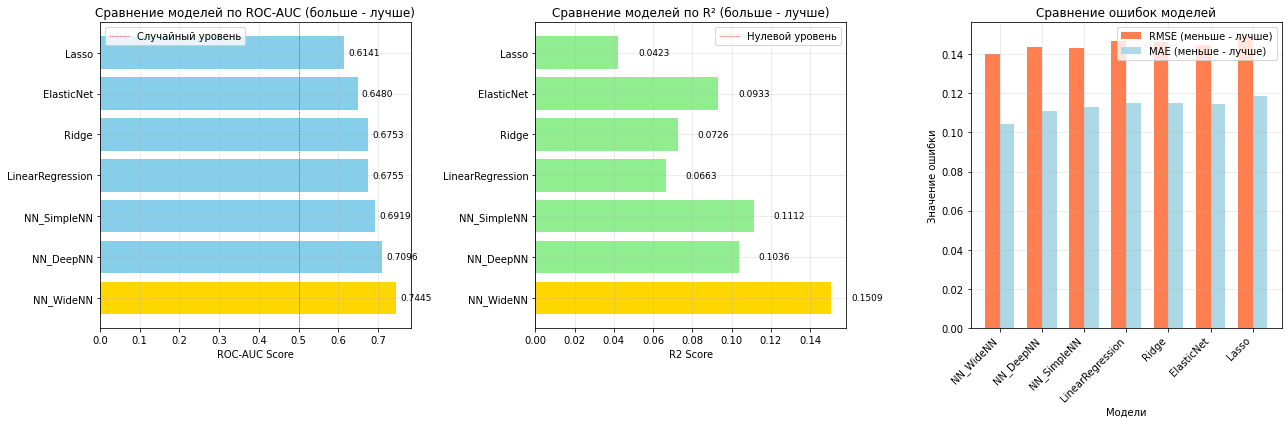

In [77]:
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛЕЙ")
print("=" * 80)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Сравнение по ROC-AUC
colors = ['gold' if x == comparison_df['ROC-AUC'].max() else 'skyblue' 
          for x in comparison_df['ROC-AUC']]
axes[0].barh(comparison_df['Модель'], comparison_df['ROC-AUC'], color=colors)
axes[0].set_xlabel('ROC-AUC Score')
axes[0].set_title('Сравнение моделей по ROC-AUC (больше - лучше)')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=0.5, label='Случайный уровень')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    axes[0].text(row['ROC-AUC'] + 0.01, i, f"{row['ROC-AUC']:.4f}", va='center', fontsize=9)

# 2. Сравнение по R2
colors = ['gold' if x == comparison_df['R2'].max() else 'lightgreen' 
          for x in comparison_df['R2']]
axes[1].barh(comparison_df['Модель'], comparison_df['R2'], color=colors)
axes[1].set_xlabel('R2 Score')
axes[1].set_title('Сравнение моделей по R² (больше - лучше)')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=0.5, label='Нулевой уровень')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    axes[1].text(row['R2'] + 0.01, i, f"{row['R2']:.4f}", va='center', fontsize=9)

# 3. Сравнение по RMSE и MAE
x = np.arange(len(comparison_df['Модель']))
width = 0.35

axes[2].bar(x - width/2, comparison_df['RMSE'], width, label='RMSE (меньше - лучше)', color='coral')
axes[2].bar(x + width/2, comparison_df['MAE'], width, label='MAE (меньше - лучше)', color='lightblue')
axes[2].set_xlabel('Модели')
axes[2].set_ylabel('Значение ошибки')
axes[2].set_title('Сравнение ошибок моделей')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comparison_df['Модель'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Отчет итоговый

In [78]:
# Отчет итоговый
print("\n" + "=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ")
print("=" * 80)

best_model = comparison_df.iloc[0]
print(f"   Лучшая модель: {best_model['Модель']}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f} ({best_model['ROC-AUC']*100:.2f}%)")
print(f"   Модель правильно определяет соответствие в {best_model['ROC-AUC']*100:.2f}% случаев")


ИТОГОВЫЙ ОТЧЕТ
   Лучшая модель: NN_WideNN
   ROC-AUC: 0.7445 (74.45%)
   Модель правильно определяет соответствие в 74.45% случаев


#### Сохранение лучшей модели

In [79]:
# Сохраняем результаты в CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)
print(f"\nРезультаты сохранены в 'model_comparison_results.csv'")


Результаты сохранены в 'model_comparison_results.csv'


**Выводы:**
- В качестве метрики качества работы модели выбрала ROC-AUC:
    - ROC-AUC (Area Under ROC Curve) - это метрика, которая показывает, насколько хорошо модель различает два класса (в внашем случае: "плохое соответствие" vs "хорошее соответствие")
    - Если целевая переменная (final_rating_сombined) от 0.5 вкл. и выше присваивается 1 ("хорошее соответствие"), иначе 0 ("плохое соответствие")
- Обучены:
    - Линейная регрессия и ее варианты
        - LinearRegression
        - Ridge
        - Lasso
        - ElasticNet
    - Полносвязные нейронные связи 
        - Простая NN (1 скрытый слой) 
        - Глубокая NN (3 скрытых слоя)
        - Широкая NN (2 скрытых слоя)
- Лучшая модель: NN_WideNN
    - ROC-AUC: 0.7445 (74.45%)
    - Модель правильно определяет соответствие в 74.45% случаев

## Тестирование модели

Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки `test_images`, выберите случайные 10 запросов из файла `test_queries.csv` и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.

In [80]:
# Список слов, указывающих на детей (до 16 лет)
child_keywords = child_keywords #список определн выше в п.2

# Функция для проверки наличия детских слов в тексте
def contains_child_keywords(text):
    """
    Проверяет, содержит ли текст слова, указывающие на детей
    Возвращает True если содержит, иначе False
    """
    text_lower = text.lower()
    for keyword in child_keywords:
        if keyword in text_lower:
            return True
    return False

In [81]:
# Пересоздаем BERT модель для поиска 
bert_tokenizer_search = transformers.BertTokenizer.from_pretrained('bert-base-cased')
bert_model_search = transformers.BertModel.from_pretrained('bert-base-cased')
bert_model_search.eval()


Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [82]:
# Выбираем случайные 10 запросов из тестовой выборки
sample_queries = df_test_q.sample(n=N, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Выбрано {len(sample_queries)} случайных запросов для оценки")
print("\nСписок выбранных запросов:")
for idx, row in sample_queries.iterrows():
    print(f"{idx+1}. {row['query_text'][:100]}...")

Выбрано 10 случайных запросов для оценки

Список выбранных запросов:
1. A group of girls who are gothically dressed standing together...
2. A woman and girl riding downhill on a sled with a dog running alongside them...
3. The dog is running ....
4. A group of people are ice skating in a big city ....
5. Little kid in blue coat and hat riding a tricycle ....
6. Two black dogs fighting over an orange toy ....
7. A dog jumping for a tennis ball near an ocean...
8. Boy flying a distant kite ....
9. kids play ultimate Frisbee ....
10. A girl in a purple shirt feeding ducks...


In [83]:
# Подготовка лучшей модели к тестированию

# Получаем лучшую модель из результатов обучения
best_model_name = comparison_df.iloc[0]['Модель']
print(f"\nЛучшая модель: {best_model_name}")

# Извлекаем лучшую модель NN_WideNN
best_nn_model = None
if best_model_name == 'NN_WideNN':
    best_nn_model = nn_results['WideNN']['model']
    best_nn_model.eval()
    print("Модель NN_WideNN загружена для тестирования")
elif best_model_name == 'NN_SimpleNN':
    best_nn_model = nn_results['SimpleNN']['model']
    best_nn_model.eval()
    print("Модель NN_SimpleNN загружена для тестирования")
elif best_model_name == 'NN_DeepNN':
    best_nn_model = nn_results['DeepNN']['model']
    best_nn_model.eval()
    print("Модель NN_DeepNN загружена для тестирования")
else:
    # Если лучшая - линейная модель
    best_linear_model = linear_results[best_model_name]['model']
    print(f"Линейная модель {best_model_name} загружена для тестирования")

# Загружаем scaler и pca (если использовались)
print("Загружены трансформации: PCA и StandardScaler")

# Функция нормализации эмбеддингов
def normalize_embedding(emb):
    """Нормализует эмбеддинг до единичной длины"""
    norm = np.linalg.norm(emb)
    if norm > 0:
        return emb / norm
    return emb

# Нормализация тестовых эмбеддингов изображений
print("\nНормализация тестовых эмбеддингов...")
test_embeddings_normalized = {}
for img_name, emb in test_embeddings.items():
    test_embeddings_normalized[img_name] = normalize_embedding(emb)
print(f"Нормализовано {len(test_embeddings_normalized)} изображений")

# ============================================
# Функция для векторизации текста 
# ============================================

def vectorize_text(text, bert_tokenizer_search, bert_model_search, max_length=128, normalize=True):
    """
    Векторизация текста с помощью BERT
    
    Args:
        text: текст для векторизации
        bert_tokenizer_search: BERT токенизатор
        bert_model_search: BERT модель
        max_length: максимальная длина последовательности
        normalize: нормализовать ли эмбеддинг
    
    Returns:
        numpy array с эмбеддингом текста
    """
    # Очистка текста
    text_clean = clean_text(text)
    
    # Лемматизация
    text_lemmatized = lemmatize_sent(text_clean)
    text_str = ' '.join(text_lemmatized)
    
    # Токенизация
    encoded = bert_tokenizer_search.encode(
        text_str,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    
    # Получение эмбеддинга
    with torch.no_grad():
        outputs = bert_model_search(encoded)
        # Берем [CLS] эмбеддинг
        embedding = outputs.last_hidden_state[:, 0, :].numpy()[0]
    
    # Нормализация
    if normalize:
        embedding = normalize_embedding(embedding)
    
    return embedding


# ============================================
# Функция для векторизации изображения
# ============================================

def vectorize_image(image_path, model_cnn, transform, normalize=True):
    """
    Векторизация изображения с помощью ResNet
    
    Args:
        image_path: путь к изображению
        model_cnn: CNN модель для извлечения признаков
        transform: трансформации для изображения
        normalize: нормализовать ли эмбеддинг
    
    Returns:
        numpy array с эмбеддингом изображения
    """
    try:
        img = Image.open(image_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0)
        
        with torch.no_grad():
            embedding = model_cnn(img_tensor)
        
        embedding = embedding[0].cpu().numpy()
        
        if normalize:
            embedding = normalize_embedding(embedding)
        
        return embedding
    except Exception as e:
        print(f"Ошибка при обработке изображения {image_path}: {e}")
        return None


# ============================================
# Основная функция поиска изображений
# ============================================

def search_images(query_text, test_images_folder, test_embeddings_dict, 
                  bert_tokenizer_search, bert_model_search, model_cnn, transform_img,
                  model_predict, scaler, pca, threshold=0.5):
    """
    Функция поиска наиболее релевантного изображения по текстовому запросу
    """
    
    # ========== ПРОВЕРКА НА ЮРИДИЧЕСКИ ВРЕДНЫЙ КОНТЕНТ ==========
    if contains_child_keywords(query_text):
        print("\n⚠️ DISCLAIMER ⚠️")
        print("This image is unavailable in your country in compliance with local laws")
        print("Данное изображение недоступно в вашей стране в соответствии с местным законодательством")
        return None, None, None
    
    # ========== ВЕКТОРИЗАЦИЯ ТЕКСТА ==========
    print(f"\nОбработка запроса: {query_text[:100]}...")
    
    # добавляем нормализацию
    text_embedding = vectorize_text(query_text, bert_tokenizer_search, bert_model_search, normalize=True)
    print(f"  Текстовый эмбеддинг: {text_embedding.shape}, норма={np.linalg.norm(text_embedding):.3f}")
    
    # ========== ВЫЧИСЛЕНИЕ ОЦЕНОК ДЛЯ ВСЕХ ИЗОБРАЖЕНИЙ ==========
    results = []
    
    for img_name, img_embedding in test_embeddings_dict.items():
        # Объединяем признаки
        combined_features = np.concatenate([text_embedding, img_embedding])
        
        # Применяем PCA (если использовался)
        if pca is not None:
            combined_features = pca.transform(combined_features.reshape(1, -1)).flatten()
        
        # Применяем StandardScaler (если использовался)
        if scaler is not None:
            combined_features = scaler.transform(combined_features.reshape(1, -1)).flatten()
        
        # Предсказание
        if model_predict is not None:
            if isinstance(model_predict, torch.nn.Module):
                # Для нейронной сети
                features_tensor = torch.FloatTensor(combined_features).reshape(1, -1)
                with torch.no_grad():
                    score = model_predict(features_tensor).item()
            elif hasattr(model_predict, 'predict'):
                # Для sklearn моделей
                score = model_predict.predict(combined_features.reshape(1, -1))[0]
            else:
                score = 0.5
        else:
            from sklearn.metrics.pairwise import cosine_similarity
            score = cosine_similarity(
                text_embedding.reshape(1, -1), 
                img_embedding.reshape(1, -1)
            )[0][0]
        
        results.append({
            'image': img_name,
            'score': score,
            'path': str(Path(test_images_folder) / img_name)
        })
    
    # ========== СОРТИРОВКА ПО УБЫВАНИЮ SCORE ==========
    results.sort(key=lambda x: x['score'], reverse=True)
    
    best_image = results[0]
    print(f"\n  Лучшее изображение: {best_image['image']}")
    print(f"  Оценка соответствия: {best_image['score']:.4f}")
    
    if best_image['score'] >= threshold:
        print(f"  Результат: СООТВЕТСТВУЕТ (score >= {threshold})")
    else:
        print(f"  Результат: НЕ СООТВЕТСТВУЕТ (score < {threshold})")
    
    return best_image, results


# ============================================
# Демонстрационная функция 
# ============================================

def demo_search(query_text, top_k=3):
    """
    Демонстрационная версия поиска изображений
    """
    
    # Проверка на детский контент
    if contains_child_keywords(query_text):
        print("\n" + "=" * 60)
        print("⚠️  DISCLAIMER  ⚠️")
        print("=" * 60)
        print("This image is unavailable in your country in compliance with local laws")
        print("Данное изображение недоступно в вашей стране")
        print("в соответствии с местным законодательством.")
        print("=" * 60)
        return []
    

    text_embedding = vectorize_text(query_text, bert_tokenizer_search, bert_model_search, normalize=True)
    
    # Вычисление оценок для всех изображений (используем нормализованные эмбеддинги)
    results = []
    
    for img_name, img_embedding in test_embeddings_normalized.items():
        combined = np.concatenate([text_embedding, img_embedding])
        
        # Применяем PCA
        combined_pca = pca.transform(combined.reshape(1, -1))
        
        # Применяем StandardScaler
        combined_scaled = scaler.transform(combined_pca)
        
        # Предсказание
        features_tensor = torch.FloatTensor(combined_scaled)
        with torch.no_grad():
            score = best_nn_model(features_tensor).item()
        
        results.append({
            'image': img_name,
            'score': score,
            'path': str(Path(path_to_image_folder_test) / img_name)
        })
    
    # Сортировка
    results.sort(key=lambda x: x['score'], reverse=True)
    
    # Вывод результатов
    print("\n" + "=" * 60)
    print(f" РЕЗУЛЬТАТЫ ПОИСКА ПО ЗАПРОСУ:")
    print(f"   \"{query_text[:80]}{'...' if len(query_text) > 80 else ''}\"")
    print("=" * 60)
    
    for i, res in enumerate(results[:top_k]):
        status = " СООТВЕТСТВУЕТ" if res['score'] >= 0.5 else "❌ НЕ СООТВЕТСТВУЕТ"
        print(f"\n{i+1}. {res['image']}")
        print(f"   Оценка: {res['score']:.4f} ({status})")
        print(f"   Путь: {res['path']}")
    
    return results[:top_k]



Лучшая модель: NN_WideNN
Модель NN_WideNN загружена для тестирования
Загружены трансформации: PCA и StandardScaler

Нормализация тестовых эмбеддингов...
Нормализовано 100 изображений


In [84]:
# ============================================
# ФУНКЦИИ ДЛЯ ОТОБРАЖЕНИЯ ИЗОБРАЖЕНИЙ
# ============================================


def show_top_images(search_results, top_k=3, query_text=None):
    """
    Отображает топ-K изображений из результатов поиска
    """
    if not search_results:
        print("   Нет результатов для отображения")
        return
    
    n_images = min(top_k, len(search_results))
    
    if n_images == 0:
        print("   Нет изображений для отображения")
        return
    
    # Создаем подграфики
    fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 5))
    if n_images == 1:
        axes = [axes]
    
    for i in range(n_images):
        img_path = search_results[i]['path']
        score = search_results[i]['score']
        
        try:
            # Загружаем изображение
            img = Image.open(img_path)
            
            # Отображаем
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"Rank {i+1}\nScore: {score:.4f}", fontsize=10)
            
            # Красная рамка для низких оценок
            if score < 0.5:
                axes[i].spines['top'].set_color('red')
                axes[i].spines['bottom'].set_color('red')
                axes[i].spines['left'].set_color('red')
                axes[i].spines['right'].set_color('red')
                axes[i].spines['top'].set_linewidth(3)
                axes[i].spines['bottom'].set_linewidth(3)
                axes[i].spines['left'].set_linewidth(3)
                axes[i].spines['right'].set_linewidth(3)
                
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Ошибка загрузки\n{img_path}", 
                        ha='center', va='center')
            axes[i].axis('off')
    
    if query_text:
        # Обрезаем длинный текст
        short_text = query_text[:60] + "..." if len(query_text) > 60 else query_text
        fig.suptitle(f"Результаты поиска: \"{short_text}\"", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def show_ground_truth_comparison(predicted_path, ground_truth_path, pred_score, gt_score, query_text):
    """
    Отображает сравнение предсказанного изображения с эталонным
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Предсказанное изображение (Топ-1)
    try:
        pred_img = Image.open(predicted_path)
        axes[0].imshow(pred_img)
        axes[0].set_title(f"Топ-1 (Модель)\nScore: {pred_score:.4f}", fontsize=12, color='blue')
        axes[0].axis('off')
    except Exception as e:
        axes[0].text(0.5, 0.5, f"Ошибка: {predicted_path}", ha='center', va='center')
        axes[0].axis('off')
    
    # Эталонное изображение (Ground Truth)
    try:
        gt_img = Image.open(ground_truth_path)
        axes[1].imshow(gt_img)
        axes[1].set_title(f"Эталон (Правильный ответ)\nScore: {gt_score:.4f}", fontsize=12, color='green')
        axes[1].axis('off')
    except Exception as e:
        axes[1].text(0.5, 0.5, f"Ошибка: {ground_truth_path}", ha='center', va='center')
        axes[1].axis('off')
    
    # Заголовок
    short_text = query_text[:50] + "..." if len(query_text) > 50 else query_text
    fig.suptitle(f"Сравнение: Предсказание vs Эталон\n\"{short_text}\"", fontsize=12)
    
    plt.tight_layout()
    plt.show()





ТЕСТИРОВАНИЕ С ОТОБРАЖЕНИЕМ ИЗОБРАЖЕНИЙ

  Диагностика перед тестированием:
  • Тестовых изображений: 100
  • Размер эмбеддинга изображения: (256,)
  • Модель: NN_WideNN
  • PCA размерность: 217
  • Scaler: 217 признаков

 ЗАПРОС 1/10
   ID: 3482859574_3908de3427.jpg#1
   Текст: A group of girls who are gothically dressed standing together
   Эталон: 3482859574_3908de3427.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ЗАПРОС 2/10
   ID: 2141713971_e25eb12712.jpg#3
   Текст: A woman and girl riding downhill on a sled with a dog running alongside them
   Эталон: 2141713971_e25eb12712.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ЗАПРОС 3/10
   ID: 3488087117_2719647989.jpg#4
   Текст: The dog is running .
   Эталон: 3488087117_2719647989.jpg

    ТОП-3 РЕЗУЛЬТАТА:
      1. ❌ 3482859574

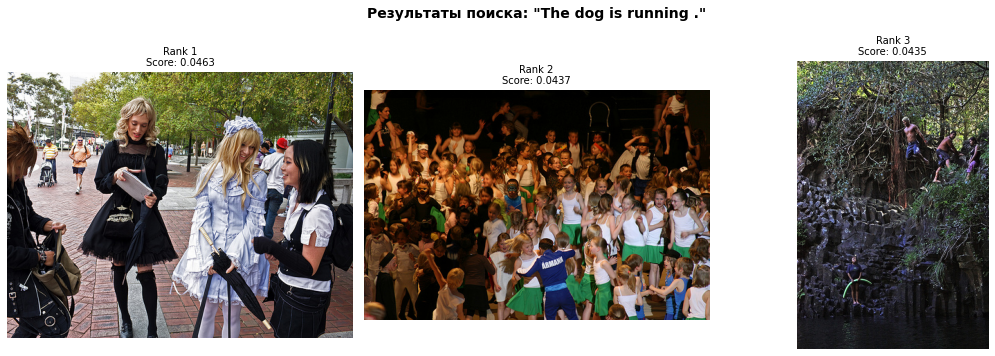


    РЕЗУЛЬТАТ: Эталон на позиции 21
   ⚠️ НУЖНО УЛУЧШИТЬ (позиция 21)


 ЗАПРОС 4/10
   ID: 269650644_059a84ece5.jpg#0
   Текст: A group of people are ice skating in a big city .
   Эталон: 269650644_059a84ece5.jpg

    ТОП-3 РЕЗУЛЬТАТА:
      1. ❌ 3482859574_3908de3427.jpg (0.0448)
      2. ❌ 2517284816_9b8fd3c6b6.jpg (0.0422)
      3. ❌ 3036971334_78187a9570.jpg (0.0420)

    ОТОБРАЖЕНИЕ ТОП-3:


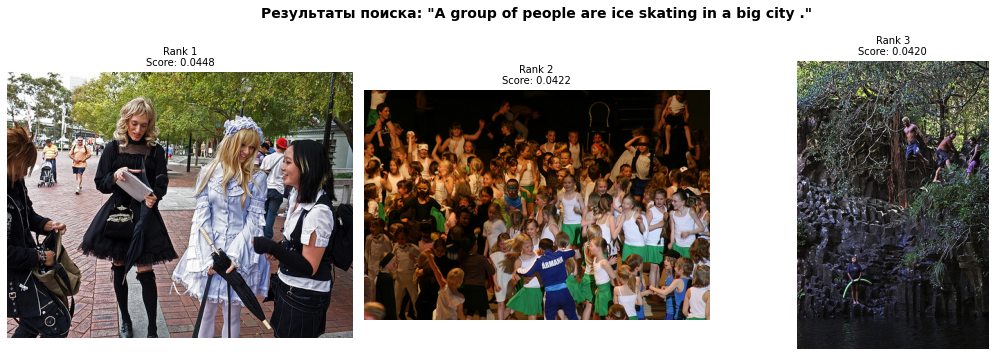


    РЕЗУЛЬТАТ: Эталон на позиции 5
   👍 ХОРОШО! Правильное изображение в топ-5

    СРАВНЕНИЕ (Топ-1 vs Эталон):


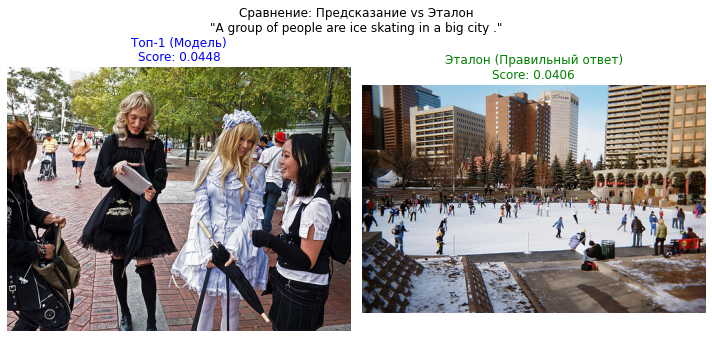



 ЗАПРОС 5/10
   ID: 2428094795_d3a8f46046.jpg#4
   Текст: Little kid in blue coat and hat riding a tricycle .
   Эталон: 2428094795_d3a8f46046.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ЗАПРОС 6/10
   ID: 3553476195_fb3747d7c1.jpg#4
   Текст: Two black dogs fighting over an orange toy .
   Эталон: 3553476195_fb3747d7c1.jpg

    ТОП-3 РЕЗУЛЬТАТА:
      1. ❌ 3482859574_3908de3427.jpg (0.0461)
      2. ❌ 2517284816_9b8fd3c6b6.jpg (0.0434)
      3. ❌ 3036971334_78187a9570.jpg (0.0433)

    ОТОБРАЖЕНИЕ ТОП-3:


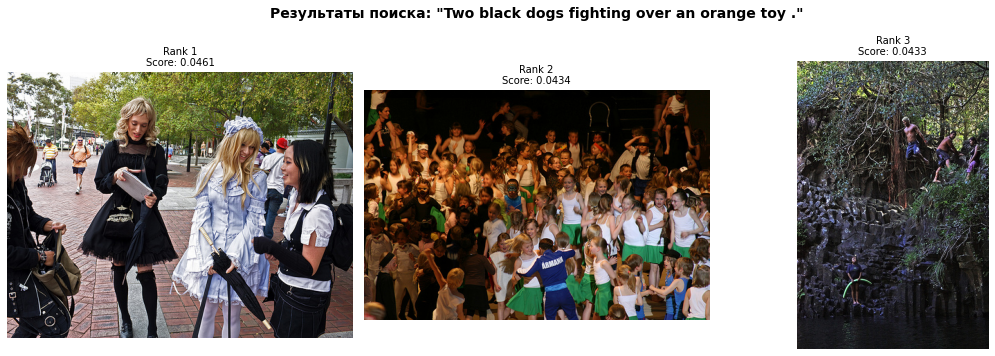


    РЕЗУЛЬТАТ: Эталон на позиции 87
   ⚠️ НУЖНО УЛУЧШИТЬ (позиция 87)


 ЗАПРОС 7/10
   ID: 3514297698_0512623955.jpg#2
   Текст: A dog jumping for a tennis ball near an ocean
   Эталон: 3514297698_0512623955.jpg

    ТОП-3 РЕЗУЛЬТАТА:
      1. ❌ 3482859574_3908de3427.jpg (0.0444)
      2. ❌ 2517284816_9b8fd3c6b6.jpg (0.0419)
      3. ❌ 3036971334_78187a9570.jpg (0.0416)

    ОТОБРАЖЕНИЕ ТОП-3:


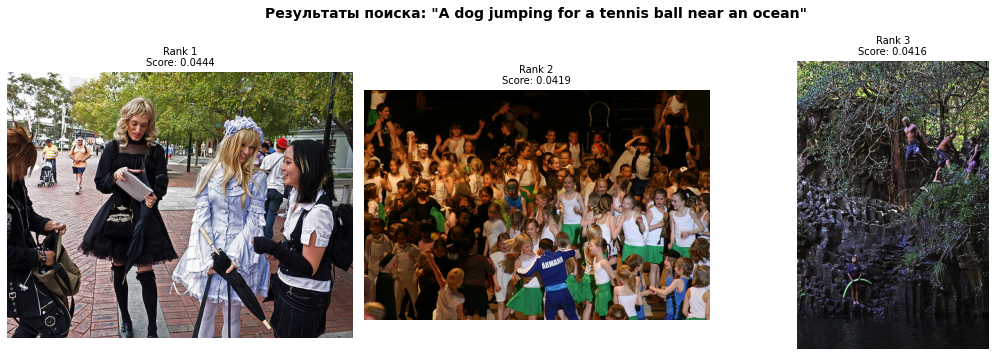


    РЕЗУЛЬТАТ: Эталон на позиции 53
   ⚠️ НУЖНО УЛУЧШИТЬ (позиция 53)


 ЗАПРОС 8/10
   ID: 2505056124_1276e8dbcb.jpg#4
   Текст: Boy flying a distant kite .
   Эталон: 2505056124_1276e8dbcb.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ЗАПРОС 9/10
   ID: 2121140070_a09644550b.jpg#3
   Текст: kids play ultimate Frisbee .
   Эталон: 2121140070_a09644550b.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ЗАПРОС 10/10
   ID: 607339469_af851c4119.jpg#0
   Текст: A girl in a purple shirt feeding ducks
   Эталон: 607339469_af851c4119.jpg

⚠️ DISCLAIMER ⚠️
This image is unavailable in your country in compliance with local laws
   ⛔ Запрос заблокирован (содержит упоминания детей)

 ИТОГОВАЯ СТАТИСТИКА ТЕСТИРОВАНИЯ

 Общая статистика:
 Всего запросов: 10
 Заблокировано (дети): 6
 Обработано успе

In [85]:
# ============================================
# ФУНКЦИЯ quick_search 
# ============================================

def quick_search_with_display(query_text, query_id=None, ground_truth=None):
    """
    Быстрый поиск с возможностью отображения изображений (ИСПРАВЛЕНА)
    """
    
    # Проверка на детский контент
    if contains_child_keywords(query_text):
        print("\n⚠️ DISCLAIMER ⚠️")
        print("This image is unavailable in your country in compliance with local laws")
        return None
    
    # ИСПРАВЛЕНО: используем bert_tokenizer_search и нормализацию
    text_embedding = vectorize_text(query_text, bert_tokenizer_search, bert_model_search, normalize=True)
    
    # Вычисление оценок (используем нормализованные эмбеддинги)
    results = []
    for img_name, img_embedding in test_embeddings_normalized.items():
        combined = np.concatenate([text_embedding, img_embedding])
        combined_pca = pca.transform(combined.reshape(1, -1))
        combined_scaled = scaler.transform(combined_pca)
        features_tensor = torch.FloatTensor(combined_scaled)
        
        with torch.no_grad():
            score = best_nn_model(features_tensor).item()
        
        results.append({
            'image': img_name,
            'score': score,
            'path': str(Path(path_to_image_folder_test) / img_name)
        })
    
    results.sort(key=lambda x: x['score'], reverse=True)
    return results


# ============================================
# ТЕСТИРОВАНИЕ С ОТОБРАЖЕНИЕМ ИЗОБРАЖЕНИЙ 
# ============================================

print("\n" + "=" * 80)
print("ТЕСТИРОВАНИЕ С ОТОБРАЖЕНИЕМ ИЗОБРАЖЕНИЙ")
print("=" * 80)

# Предварительная диагностика
print("\n  Диагностика перед тестированием:")
print(f"  • Тестовых изображений: {len(test_embeddings_normalized)}")
print(f"  • Размер эмбеддинга изображения: {list(test_embeddings_normalized.values())[0].shape if test_embeddings_normalized else 'N/A'}")
print(f"  • Модель: {best_model_name}")
print(f"  • PCA размерность: {pca.n_components_}")
print(f"  • Scaler: {scaler.mean_.shape[0]} признаков")

test_results = []

for idx, row in sample_queries.iterrows():
    query_text = row['query_text']
    query_id = row['query_id']
    ground_truth = row['image'] if 'image' in row else None
    
    print(f"\n{'='*60}")
    print(f" ЗАПРОС {idx+1}/{len(sample_queries)}")
    print(f"   ID: {query_id}")
    print(f"   Текст: {query_text[:150]}")
    if ground_truth:
        print(f"   Эталон: {ground_truth}")
    print(f"{'='*60}")
    
    # Выполняем поиск
    search_results = quick_search_with_display(query_text, query_id, ground_truth)
    
    if search_results is None:
        print("   ⛔ Запрос заблокирован (содержит упоминания детей)")
        continue
    
    # Выводим топ-3 текстом
    print(f"\n    ТОП-3 РЕЗУЛЬТАТА:")
    for i, res in enumerate(search_results[:3]):
        status = "✅" if res['score'] >= 0.5 else "❌"
        print(f"      {i+1}. {status} {res['image']} ({res['score']:.4f})")
    
    # ОТОБРАЖАЕМ ТОП-3 ИЗОБРАЖЕНИЯ
    print(f"\n    ОТОБРАЖЕНИЕ ТОП-3:")
    show_top_images(search_results, top_k=3, query_text=query_text)
    
    # Проверяем эталон
    if ground_truth:
        rank = None
        for i, res in enumerate(search_results):
            if res['image'] == ground_truth:
                rank = i + 1
                break
        
        if rank:
            print(f"\n    РЕЗУЛЬТАТ: Эталон на позиции {rank}")
            if rank == 1:
                print("   ✅ ОТЛИЧНО! Модель выбрала правильное изображение!")
            elif rank <= 5:
                print("   👍 ХОРОШО! Правильное изображение в топ-5")
            else:
                print(f"   ⚠️ НУЖНО УЛУЧШИТЬ (позиция {rank})")
            
            # ПОКАЗЫВАЕМ СРАВНЕНИЕ, если эталон не на первом месте
            if rank != 1 and rank <= 10:
                print(f"\n    СРАВНЕНИЕ (Топ-1 vs Эталон):")
                gt_path = str(Path(path_to_image_folder_test) / ground_truth)
                if Path(gt_path).exists():
                    show_ground_truth_comparison(
                        search_results[0]['path'],
                        gt_path,
                        search_results[0]['score'],
                        search_results[rank-1]['score'],
                        query_text
                    )
        else:
            print(f"\n   ❌ Эталон НЕ НАЙДЕН в результатах поиска")
    
    print()


# ============================================
# ИТОГОВАЯ СТАТИСТИКА
# ============================================

print("\n" + "=" * 80)
print(" ИТОГОВАЯ СТАТИСТИКА ТЕСТИРОВАНИЯ")
print("=" * 80)

total_queries = len(sample_queries)
blocked = sum(1 for _, row in sample_queries.iterrows() if contains_child_keywords(row['query_text']))
processed = total_queries - blocked

print(f"\n Общая статистика:")
print(f" Всего запросов: {total_queries}")
print(f" Заблокировано (дети): {blocked}")
print(f" Обработано успешно: {processed}")

print("\n" + "=" * 80)
print(" ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
print("=" * 80)

## Выводы

- данные загружены 
- из df искл. экспертные оценки, где менее 2-х одинаковых оценок из 3-х
- целевая переменная final_rating_сombined объединяет экспертную оценку с весом .6  и краудсорсинговую оценки с весом .4  и варируется от 0 до 1
- данные предобработаны: приведены к нижнему регистру, удалены URL,HTML теги, удалены пунктуация и цифры (оставляем только буквы и пробелы), удалены лишние пробелы
- данные лематизированы
- все изображения, которые нарушают закон (т.е. содержат изображение ребенка), удалены из обучающей выборки. Их кол-во 1661. Для дальнейшего использования df_train_law
- количество уникальных image в df_train_law: 991
- векторизация изображений произведена
- векторизация текстов произведена
- получен df_model, который объединяет векторы изображений (image_embeddings) и векторы текстов (bert_embeddings) с целевой НЕпустой переменной (final_rating_сombined) и содержит только уникальные значения image и query_id
- метрика качества работы модели выбрала ROC-AUC
    - ROC-AUC (Area Under ROC Curve) - это метрика, которая показывает, насколько хорошо модель различает два класса (в внашем случае: "плохое соответствие" vs "хорошее соответствие")
    - если целевая переменная (final_rating_сombined) от 0.5 вкл. и выше присваивается 1 ("хорошее соответствие"), иначе 0 ("плохое соответствие")
- обучены:
    - Линейная регрессия и ее варианты
    - Полносвязные нейронные связи 
- Лучшая модель: NN_WideNN
    - ROC-AUC: 0.7445 (74.45%)
    - Модель правильно определяет соответствие в 74.45% случаев
- Тестирование модели проведено, модель не показывает изображения при детском контенте и показывает изображения при его отсутствии. 

- [x] Jupyter Notebook открыт
- [x] Весь код выполняется без ошибок
- [x] Ячейки с кодом расположены в порядке исполнения
- [x] Исследовательский анализ данных выполнен
- [x] Проверены экспертные оценки и краудсорсинговые оценки
- [x] Из датасета исключены те объекты, которые выходят за рамки юридических ограничений
- [x] Изображения векторизованы
- [x] Текстовые запросы векторизованы
- [x] Данные корректно разбиты на тренировочную и тестовую выборки
- [x] Предложена метрика качества работы модели
- [x] Предложена модель схожести изображений и текстового запроса
- [x] Модель обучена
- [x] По итогам обучения модели сделаны выводы
- [x] Проведено тестирование работы модели
- [x] По итогам тестирования визуально сравнили качество поиска